# Metal Prices in Transition

This notebook reproduces the main figures used in the poster, and progress presentation. It also rebuilds the monthly regression panel from the raw source files so the core results can be checked directly inside the repository.

The notebook focuses on five tasks:

1. Check the included datasets and confirm the sample windows
2. Rebuild the monthly modeling panel from the raw source files
3. Re-estimate the main HAC regressions and copper inventory model
4. Reproduce the historical and structural figures used in the project
5. Summarize the long-run scenario paths and Monte Carlo ranges


In [2]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root from current working directory.")

ROOT = find_repo_root()
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
FIG = ROOT / "figures"


In [3]:

monthly = pd.read_csv(PROC / "Monthly Model Complete.csv", parse_dates=["Month"])
metal = pd.read_csv(PROC / "Metal Panel Long.csv", parse_dates=["Month"])
struct = pd.read_csv(PROC / "Structural Inputs.csv")
reg = pd.read_csv(PROC / "Regression Results.csv")
lt = pd.read_csv(PROC / "Long Term Paths.csv")
mc = pd.read_csv(PROC / "Monte Carlo Yearly Percentiles.csv")

summary = pd.DataFrame({
    "Dataset": [
        "Monthly Model Complete",
        "Metal Panel Long",
        "Structural Inputs",
        "Regression Results",
        "Long Term Paths",
        "Monte Carlo Yearly Percentiles",
    ],
    "Rows": [len(monthly), len(metal), len(struct), len(reg), len(lt), len(mc)],
    "Columns": [monthly.shape[1], metal.shape[1], struct.shape[1], reg.shape[1], lt.shape[1], mc.shape[1]],
})
display(summary)


,Dataset,Rows,Columns
0,Monthly Model Complete,116,28
1,Metal Panel Long,1878,5
2,Structural Inputs,40,8
3,Regression Results,51,8
4,Long Term Paths,156,16
5,Monte Carlo Yearly Percentiles,52,10


## 0. Data checks and reproducibility

Before plotting anything, we checked the included files and the core sample windows. This is useful because the project uses both long historical series and narrower modeling samples, and I want the notebook to make that distinction explicit.


In [43]:

def dataset_span(df):
    if "Month" in df.columns:
        vals = pd.to_datetime(df["Month"])
        return f"{vals.min().date()} to {vals.max().date()}"
    if "Year" in df.columns:
        vals = pd.to_numeric(df["Year"], errors="coerce")
        vals = vals.dropna()
        return f"{int(vals.min())} to {int(vals.max())}"
    return "n/a"

qc = pd.DataFrame({
    "Dataset": [
        "Monthly Model Complete",
        "Metal Panel Long",
        "Structural Inputs",
        "Regression Results",
        "Long Term Paths",
        "Monte Carlo Yearly Percentiles",
    ],
    "Rows": [
        len(monthly),
        len(metal),
        len(struct),
        len(reg),
        len(lt),
        len(mc),
    ],
    "Columns": [
        monthly.shape[1],
        metal.shape[1],
        struct.shape[1],
        reg.shape[1],
        lt.shape[1],
        mc.shape[1],
    ],
    "Sample window": [
        dataset_span(monthly),
        dataset_span(metal),
        dataset_span(struct),
        "saved output table",
        dataset_span(lt),
        dataset_span(mc),
    ],
    "Duplicate rows": [
        int(monthly.duplicated().sum()),
        int(metal.duplicated().sum()),
        int(struct.duplicated().sum()),
        int(reg.duplicated().sum()),
        int(lt.duplicated().sum()),
        int(mc.duplicated().sum()),
    ],
    "Missing cells": [
        int(monthly.isna().sum().sum()),
        int(metal.isna().sum().sum()),
        int(struct.isna().sum().sum()),
        int(reg.isna().sum().sum()),
        int(lt.isna().sum().sum()),
        int(mc.isna().sum().sum()),
    ],
})

raw_inventory = pd.DataFrame({
    "Raw source file": sorted([p.name for p in RAW.glob("*.csv")]),
})

display(qc)
display(raw_inventory)


,Dataset,Rows,Columns,Sample window,Duplicate rows,Missing cells
0,Monthly Model Complete,116,28,2016-03-01 to 2025-12-01,0,0
1,Metal Panel Long,1878,5,2000-02-01 to 2026-02-01,0,0
2,Structural Inputs,40,8,2014 to 2040,0,0
3,Regression Results,51,8,saved output table,0,18
4,Long Term Paths,156,16,2025 to 2050,0,30
5,Monte Carlo Yearly Percentiles,52,10,2025 to 2050,0,0


,Raw source file
0,Broad Dollar Original Download.csv
1,Broad Dollar Source.csv
2,Copper LME Stocks Source.csv
3,Copper Structural Source.csv
4,OECD Industrial Production Source.csv
5,Prices Monthly Source.csv
6,SP500 Raw.csv
7,Silver Structural Source.csv
8,USGS Selected Metals.csv
9,Unemployment Raw.csv


The key point from these checks is that the **core modeling tables are clean and reproducible**. The long metal panel is duplicate-free, the complete-case monthly panel has no missing cells, and the regression notebook can be traced back to the raw price, macro, and inventory files included in `data/raw/`.


## 0b. Rebuilding the monthly regression panel from raw source files

The paper uses a wider macro panel than the complete-case table in `data/processed/Monthly Model Complete.csv`, so we rebuilt the regression sample directly from the raw files below. 


In [46]:

# Raw source files needed for the monthly regression panel
prices_raw = pd.read_csv(RAW / "Prices Monthly Source.csv", parse_dates=["Month"]).sort_values("Month")
broad_raw = pd.read_csv(RAW / "Broad Dollar Source.csv", parse_dates=["Month"]).sort_values("Month")
oecd_raw = pd.read_csv(RAW / "OECD Industrial Production Source.csv", parse_dates=["Month"]).sort_values("Month")
unrate_raw = pd.read_csv(RAW / "Unemployment Raw.csv", parse_dates=["observation_date"]).rename(columns={"observation_date": "Month"}).sort_values("Month")
vix_raw = pd.read_csv(RAW / "VIX Raw.csv", parse_dates=["observation_date"]).rename(columns={"observation_date": "Date", "VIXCLS": "VIX"}).sort_values("Date")
ys_raw = pd.read_csv(RAW / "Yield Spread Raw.csv", parse_dates=["observation_date"]).rename(columns={"observation_date": "Date", "T10Y2Y": "TermSpread"}).sort_values("Date")
stocks_raw = pd.read_csv(RAW / "Copper LME Stocks Source.csv", parse_dates=["Month"]).sort_values("Month")

price_cols = [
    "Oil_USD_per_bbl",
    "Aluminum_USD_per_mt",
    "Copper_USD_per_mt",
    "Nickel_USD_per_mt",
    "Zinc_USD_per_mt",
    "Gold_USD_per_troy_oz",
    "Silver_USD_per_troy_oz",
]

panel_raw = prices_raw[["Month", *price_cols]].copy()
for col in price_cols:
    panel_raw[col.replace("USD_per_bbl", "LogReturn").replace("USD_per_mt", "LogReturn").replace("USD_per_troy_oz", "LogReturn")] = np.log(panel_raw[col]).diff()

vix_raw["Month"] = vix_raw["Date"].dt.to_period("M").dt.to_timestamp()
vix_month = vix_raw.groupby("Month", as_index=False)["VIX"].mean().rename(columns={"VIX": "VIX_MonthlyAvg"})
vix_month["Delta_VIX"] = vix_month["VIX_MonthlyAvg"].diff()

ys_raw["Month"] = ys_raw["Date"].dt.to_period("M").dt.to_timestamp()
ys_month = ys_raw.groupby("Month", as_index=False)["TermSpread"].mean().rename(columns={"TermSpread": "TermSpread_MonthlyAvg"})
ys_month["Lag_TermSpread"] = ys_month["TermSpread_MonthlyAvg"].shift(1)

unrate_raw["Month"] = unrate_raw["Month"].dt.to_period("M").dt.to_timestamp()
unrate_raw["Delta_UNRATE"] = unrate_raw["UNRATE"].diff()

broad_raw["Broad_Dollar_LogReturn"] = np.log(broad_raw["Broad_Dollar_Index"]).diff()
stocks_raw["LME_Copper_Stocks_LogChange"] = np.log(stocks_raw["LME_Copper_Stocks_tonnes"]).diff()

monthly_rebuilt = panel_raw.merge(vix_month[["Month", "VIX_MonthlyAvg", "Delta_VIX"]], on="Month", how="left")
monthly_rebuilt = monthly_rebuilt.merge(ys_month[["Month", "TermSpread_MonthlyAvg", "Lag_TermSpread"]], on="Month", how="left")
monthly_rebuilt = monthly_rebuilt.merge(unrate_raw[["Month", "UNRATE", "Delta_UNRATE"]], on="Month", how="left")
monthly_rebuilt = monthly_rebuilt.merge(broad_raw[["Month", "Broad_Dollar_Index", "Broad_Dollar_LogReturn"]], on="Month", how="left")
monthly_rebuilt = monthly_rebuilt.merge(oecd_raw, on="Month", how="left")
monthly_rebuilt = monthly_rebuilt.merge(stocks_raw[["Month", "LME_Copper_Stocks_tonnes", "LME_Copper_Stocks_LogChange"]], on="Month", how="left")

monthly_rebuilt = monthly_rebuilt[(monthly_rebuilt["Month"] >= "2010-01-01") & (monthly_rebuilt["Month"] <= "2025-12-01")].copy()

rebuilt_summary = pd.DataFrame({
    "Statistic": ["Rows before lags", "Start month", "End month", "Duplicate rows", "Missing cells"],
    "Value": [
        len(monthly_rebuilt),
        monthly_rebuilt["Month"].min().date(),
        monthly_rebuilt["Month"].max().date(),
        int(monthly_rebuilt.duplicated().sum()),
        int(monthly_rebuilt.isna().sum().sum()),
    ],
})

display(rebuilt_summary)


,Statistic,Value
0,Rows before lags,192
1,Start month,2010-01-01
2,End month,2025-12-01
3,Duplicate rows,0
4,Missing cells,8


## 0c. Re-estimating the main models from the rebuilt panel

We used HAC standard errors so the results are more reliable when returns are serially correlated or when volatility changes over time.


In [50]:

def fit_hac_model(df, y_col, x_cols, maxlags=3):
    model_df = df[[y_col, *x_cols]].copy()
    model_df["Lag_Return"] = df[y_col].shift(1)
    model_df = model_df[["Lag_Return", *x_cols, y_col]].dropna()
    X = sm.add_constant(model_df[["Lag_Return", *x_cols]])
    y = model_df[y_col]
    fit = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return fit

expanded_x = [
    "Oil_LogReturn",
    "Delta_VIX",
    "Lag_TermSpread",
    "Delta_UNRATE",
    "Broad_Dollar_LogReturn",
    "OECD_Industrial_Production_Growth_MoM_pct",
]

metal_names = ["Aluminum", "Copper", "Nickel", "Zinc", "Gold", "Silver"]
reestimated_rows = []

for metal_name in metal_names:
    fit = fit_hac_model(monthly_rebuilt, f"{metal_name}_LogReturn", expanded_x, maxlags=3)
    reestimated_rows.append({
        "Metal": metal_name,
        "Broad dollar coefficient (re-estimated)": fit.params["Broad_Dollar_LogReturn"],
        "p-value": fit.pvalues["Broad_Dollar_LogReturn"],
        "Adjusted R²": fit.rsquared_adj,
        "N": int(fit.nobs),
    })

reestimated_bd = pd.DataFrame(reestimated_rows)

saved_bd = reg[(reg["Model"] == "Expanded HAC Regression") & (reg["Variable"] == "Broad_Dollar_LogReturn")][["Metal", "Coefficient"]].rename(columns={"Coefficient": "Broad dollar coefficient (saved table)"})

bd_check = reestimated_bd.merge(saved_bd, on="Metal", how="left")
bd_check["Difference"] = bd_check["Broad dollar coefficient (re-estimated)"] - bd_check["Broad dollar coefficient (saved table)"]

display(bd_check.round(6))

# Copper inventory model
inventory_df = monthly_rebuilt[[
    "Month",
    "Copper_LogReturn",
    "OECD_Industrial_Production_Growth_MoM_pct",
    "LME_Copper_Stocks_LogChange",
]].copy()
inventory_df["Copper_LogReturn_Lag1"] = inventory_df["Copper_LogReturn"].shift(1)
inventory_df = inventory_df.dropna()

X_inv = sm.add_constant(inventory_df[[
    "Copper_LogReturn_Lag1",
    "OECD_Industrial_Production_Growth_MoM_pct",
    "LME_Copper_Stocks_LogChange",
]])
y_inv = inventory_df["Copper_LogReturn"]
fit_inv = sm.OLS(y_inv, X_inv).fit(cov_type="HAC", cov_kwds={"maxlags": 3})

inv_table = pd.DataFrame({
    "Variable": fit_inv.params.index,
    "Coefficient": fit_inv.params.values,
    "p-value": fit_inv.pvalues.values,
})

display(inv_table.round(6))


,Metal,Broad dollar coefficient (re-estimated),p-value,Adjusted R²,N,Broad dollar coefficient (saved table),Difference
0,Aluminum,-1.174815,0.000029,0.259807,189,-1.174815,0.0
1,Copper,-1.503858,0.000005,0.335966,189,-1.503858,0.0
2,Nickel,-1.651546,0.000096,0.213006,189,-1.651546,-0.0
3,Zinc,-1.705088,0.000018,0.212601,189,-1.705088,0.0
4,Gold,-1.318581,0.000000,0.248890,189,-1.318581,-0.0
5,Silver,-2.151874,0.000000,0.247084,189,-2.151874,0.0


,Variable,Coefficient,p-value
0,const,0.001320,0.681870
1,Copper_LogReturn_Lag1,0.171126,0.009431
2,OECD_Industrial_Production_Growth_MoM_pct,0.004143,0.019191
3,LME_Copper_Stocks_LogChange,-0.058950,0.000003


The broad-dollar coefficients line up with the saved output table, which is a good check that the pipeline is internally consistent. The copper inventory model also reproduces the same qualitative result used in the paper: **copper returns rise when exchange stocks tighten**.


## 1. Long-run indexed metal prices

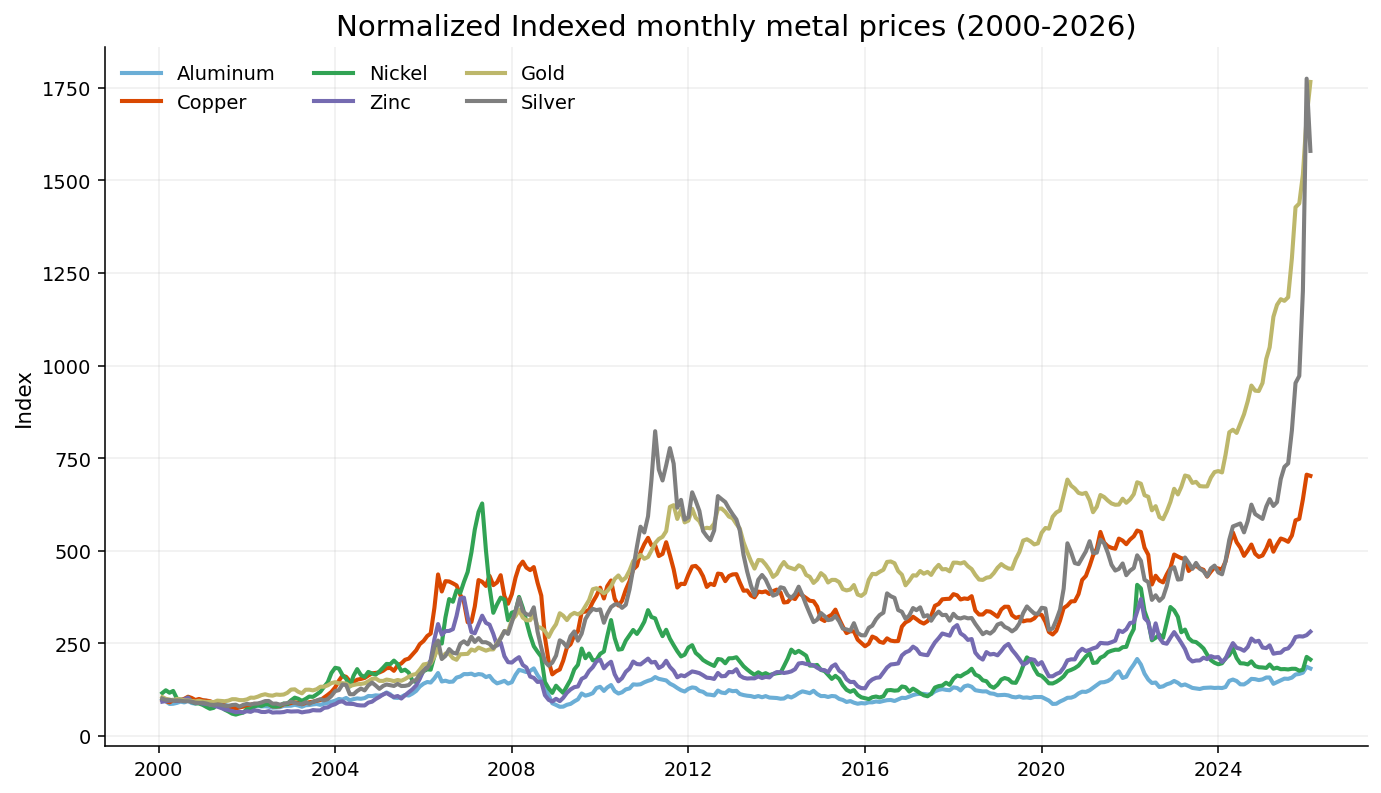

In [54]:

colors = {
    "Aluminum": "#6baed6",
    "Copper": "#d94801",
    "Nickel": "#31a354",
    "Zinc": "#756bb1",
    "Gold": "#bdb76b",
    "Silver": "#7f7f7f",
}

pivot_index = metal.pivot(index="Month", columns="Metal", values="Norm_2000M01_100").sort_index()
order = ["Aluminum", "Copper", "Nickel", "Zinc", "Gold", "Silver"]

fig, ax = plt.subplots(figsize=(10, 5.8))
for m in order:
    ax.plot(pivot_index.index, pivot_index[m], lw=2.1, label=m, color=colors[m])

ax.set_title("Normalized Indexed monthly metal prices (2000-2026)")
ax.set_ylabel("Index")
ax.grid(alpha=0.2)
ax.legend(ncol=3, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()



This figure is the broad historical motivation for the project. The metals do **not** share one common price path, which is why the paper does not treat the metal complex as one uniform market.


## 2. Correlation matrix of monthly returns

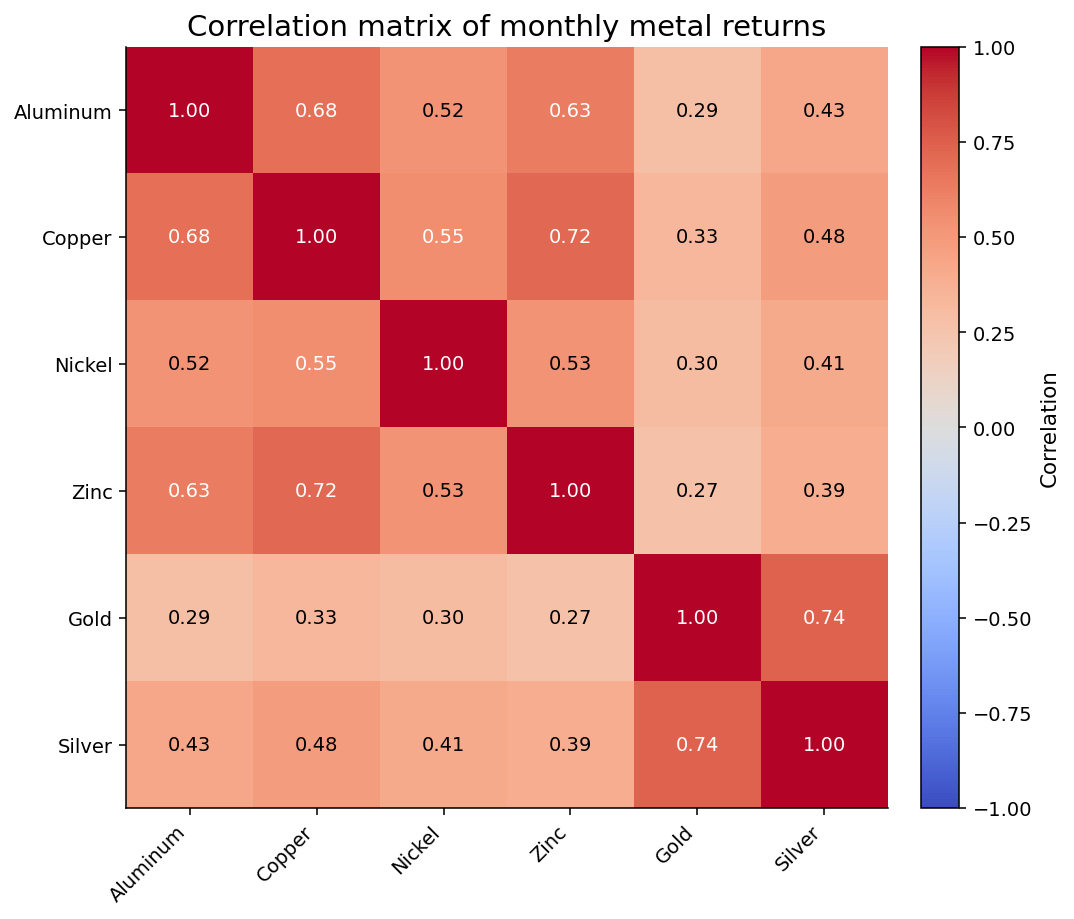

Metal,Copper,Silver,Gold
Metal,,,
Copper,1.000000,0.482691,0.329595
Silver,0.482691,1.000000,0.737266
Gold,0.329595,0.737266,1.000000


In [58]:

returns = metal.pivot(index="Month", columns="Metal", values="LogReturn").sort_index()
corr = returns.corr().loc[order, order]

fig, ax = plt.subplots(figsize=(7.6, 6.7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(order)))
ax.set_yticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_yticklabels(order)
ax.set_title("Correlation matrix of monthly metal returns")
for i in range(len(order)):
    for j in range(len(order)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.55 else "black", fontsize=10)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")
plt.tight_layout()
plt.show()

corr.loc[["Copper", "Silver", "Gold"], ["Copper", "Silver", "Gold"]]



The correlation matrix is useful because it shows **why silver is tricky**. It still has strong overlap with gold, but it also retains meaningful co-movement with industrial metals such as copper.


## 3. Copper and silver structural evidence

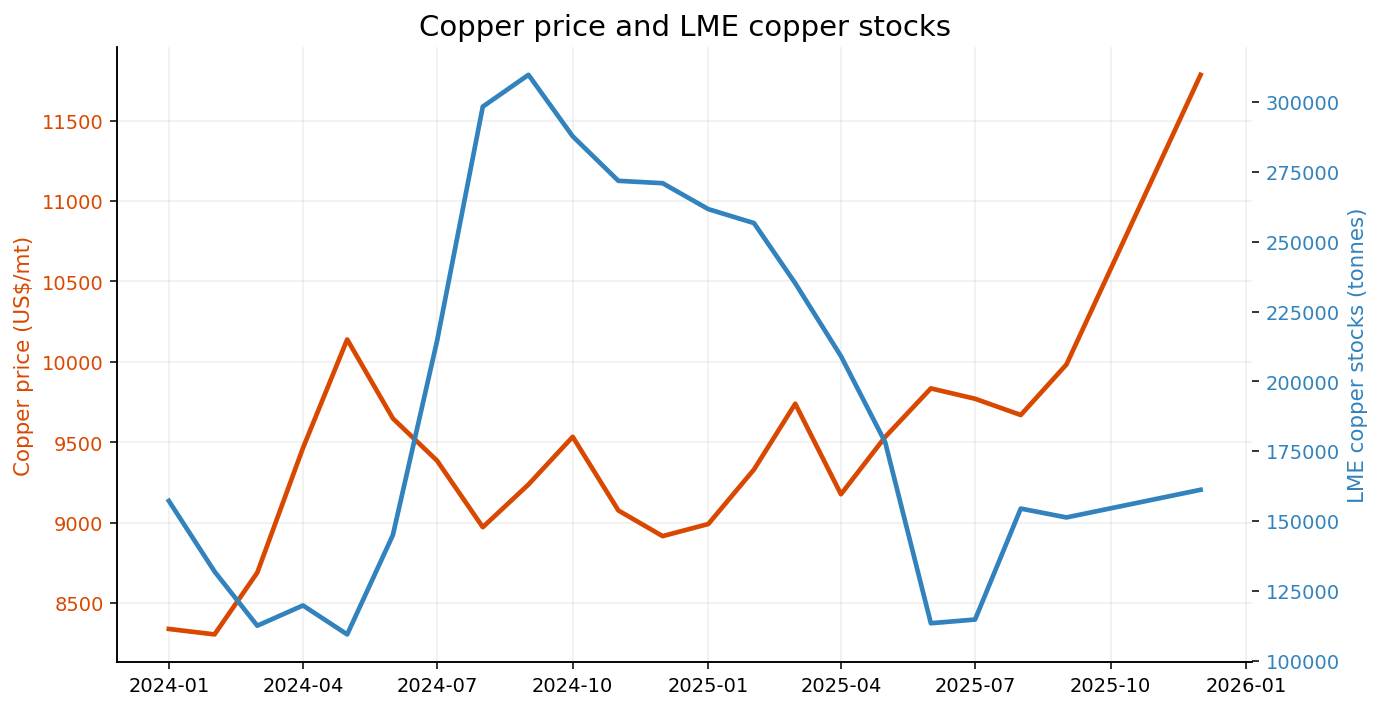

,date,value
0,2025-01,261651.000000
1,2025-06,113399.000000
2,drawdown_pct,-56.660208


In [26]:

# Copper: price and inventories
copper_monthly = monthly[["Month", "Copper_USD_per_mt", "LME_Copper_Stocks_tonnes"]].copy()
copper_plot = copper_monthly[copper_monthly["Month"] >= "2024-01-01"].copy()

fig, ax1 = plt.subplots(figsize=(10, 5.2))
ax1.plot(copper_plot["Month"], copper_plot["Copper_USD_per_mt"], lw=2.4, color="#d94801")
ax1.set_ylabel("Copper price (US$/mt)", color="#d94801")
ax1.tick_params(axis="y", labelcolor="#d94801")
ax1.set_title("Copper price and LME copper stocks")
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()
ax2.plot(copper_plot["Month"], copper_plot["LME_Copper_Stocks_tonnes"], lw=2.4, color="#3182bd")
ax2.set_ylabel("LME copper stocks (tonnes)", color="#3182bd")
ax2.tick_params(axis="y", labelcolor="#3182bd")

plt.tight_layout()
plt.show()

jan_2025 = float(copper_plot.loc[copper_plot["Month"] == "2025-01-01", "LME_Copper_Stocks_tonnes"].iloc[0])
jun_2025 = float(copper_plot.loc[copper_plot["Month"] == "2025-06-01", "LME_Copper_Stocks_tonnes"].iloc[0])
drawdown_pct = (jun_2025 / jan_2025 - 1) * 100
pd.DataFrame({
    "date": ["2025-01", "2025-06", "drawdown_pct"],
    "value": [jan_2025, jun_2025, drawdown_pct]
})


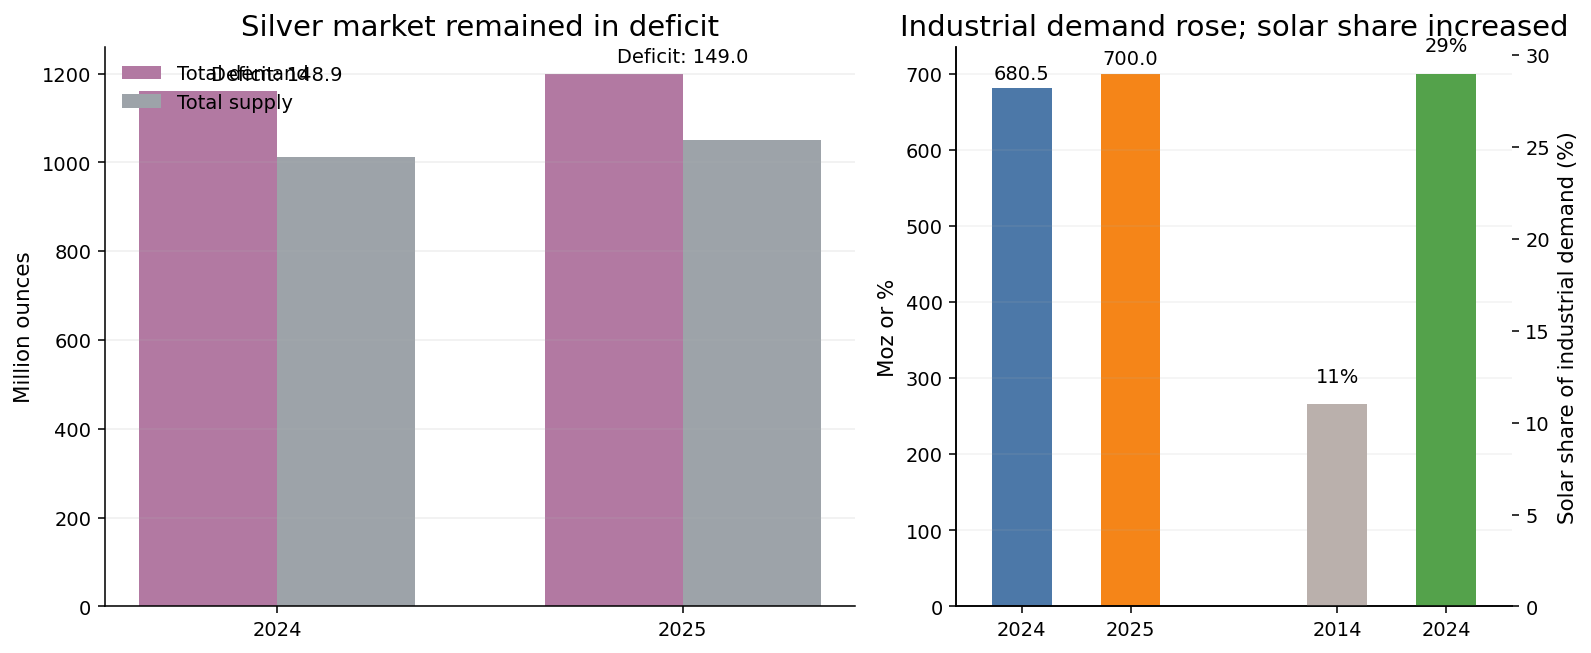

In [60]:

silver = struct[struct["Metal"] == "Silver"].copy()
silver["Year"] = silver["Year"].astype(str)

ds = silver[silver["Series"].isin(["Total demand", "Total supply"])].copy()
pivot_ds = ds.pivot(index="Year", columns="Series", values="Value").loc[["2024", "2025"]]

ind = silver[silver["Series"].isin(["Industrial demand", "Solar PV share of industrial demand"])].copy()
ind_pivot = ind.pivot(index="Year", columns="Series", values="Value")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), gridspec_kw={"width_ratios": [1.35, 1]})
x = np.arange(len(pivot_ds.index))
w = 0.34

axes[0].bar(x - w/2, pivot_ds["Total demand"], width=w, color="#b279a2", label="Total demand")
axes[0].bar(x + w/2, pivot_ds["Total supply"], width=w, color="#9da3a9", label="Total supply")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["2024", "2025"])
axes[0].set_ylabel("Million ounces")
axes[0].set_title("Silver market remained in deficit")
axes[0].legend(frameon=False, loc="upper left")
axes[0].grid(axis="y", alpha=0.2)

for xpos, year in zip(x, pivot_ds.index):
    deficit = pivot_ds.loc[year, "Total demand"] - pivot_ds.loc[year, "Total supply"]
    axes[0].text(xpos, max(pivot_ds.loc[year]) + 25, f"Deficit: {deficit:.1f}", ha="center", fontsize=10)

ind_vals = [ind_pivot.loc["2024", "Industrial demand"], ind_pivot.loc["2025", "Industrial demand"]]
axes[1].bar([0, 1], ind_vals, color=["#4c78a8", "#f58518"], width=0.55)
axes[1].set_xticks([0, 1, 2.9, 3.9])
axes[1].set_xticklabels(["2024", "2025", "2014", "2024"])
axes[1].set_title("Industrial demand rose; solar share increased")
axes[1].set_ylabel("Moz or %")
axes[1].grid(axis="y", alpha=0.15)

axr = axes[1].twinx()
axr.bar([2.9, 3.9], [11, 29], color=["#bab0ac", "#54a24b"], width=0.55)
axr.set_ylabel("Solar share of industrial demand (%)")

for xpos, val in zip([0, 1], ind_vals):
    axes[1].text(xpos, val + 12, f"{val:.1f}", ha="center", fontsize=10)
for xpos, val in zip([2.9, 3.9], [11, 29]):
    axr.text(xpos, val + 1.2, f"{val:.0f}%", ha="center", fontsize=10)

axes[1].set_xlim(-0.6, 4.5)
plt.tight_layout()
plt.show()



These two visuals are the clearest structural motivation in the project:

- **Copper:** exchange inventories fell sharply while the price stayed firm.
- **Silver:** demand exceeded supply and industrial/solar demand continued to strengthen.


## 4. Deterministic scenario paths and Monte Carlo ranges

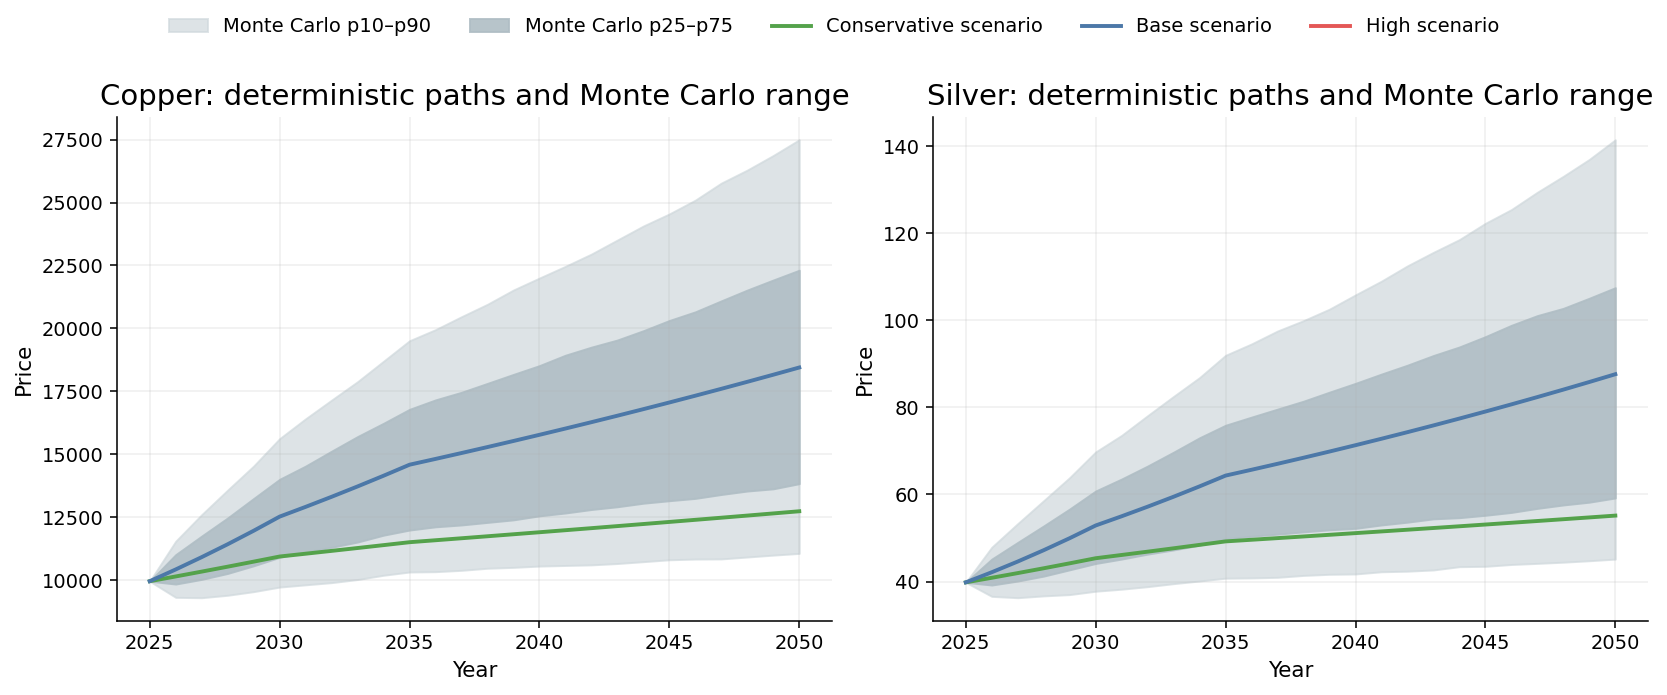

In [32]:

palette = {"Conservative": "#54a24b", "Base": "#4c78a8", "High": "#e45756"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))
for ax, metal_name in zip(axes, ["Copper", "Silver"]):
    mc_m = mc[mc["Metal"] == metal_name].sort_values("Year")
    lt_m = lt[(lt["Metal"] == metal_name) & (lt["Scenario"].isin(["Conservative", "Base", "High"]))].sort_values("Year")

    ax.fill_between(mc_m["Year"], mc_m["Price_p10"], mc_m["Price_p90"], color="#cfd8dc", alpha=0.7, label="Monte Carlo p10–p90")
    ax.fill_between(mc_m["Year"], mc_m["Price_p25"], mc_m["Price_p75"], color="#b0bec5", alpha=0.9, label="Monte Carlo p25–p75")

    for scen in ["Conservative", "Base", "High"]:
        sub = lt_m[lt_m["Scenario"] == scen]
        ax.plot(sub["Year"], sub["Price"], lw=2, color=palette[scen], label=f"{scen} scenario")

    ax.set_title(f"{metal_name}: deterministic paths and Monte Carlo range")
    ax.set_xlabel("Year")
    ax.set_ylabel("Price")
    ax.grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
seen, keep = set(), []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        keep.append((h, l))
fig.legend([k[0] for k in keep], [k[1] for k in keep], loc="upper center", ncol=5, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()



The project deliberately treats the long-run section as **scenario analysis**, not a claim that one exact price will happen. The Monte Carlo bands are there to show uncertainty around the deterministic paths rather than hide it.


## 5. Compact model takeaway table

In [36]:

# Main regression takeaway: broad-dollar coefficients
bd = reg[(reg["Model"] == "Expanded HAC Regression") & (reg["Variable"] == "Broad_Dollar_LogReturn")].copy()
bd = bd[["Metal", "Coefficient", "p_value", "Adj_R2", "N"]].sort_values("Coefficient")
bd = bd.rename(columns={"p_value": "p-value", "Adj_R2": "Adjusted R²"})
display(bd)

# Copper inventory model terms
copper_inv = reg[reg["Model"] == "Copper Inventory Model"][["Variable", "Coefficient", "p_value"]].copy()
copper_inv = copper_inv.rename(columns={"p_value": "p-value"})
display(copper_inv)


,Metal,Coefficient,p-value,Adjusted R²,N
40,Silver,-2.151874,2.341296e-09,0.247084,189.0
26,Zinc,-1.705088,1.803752e-05,0.212601,189.0
19,Nickel,-1.651546,9.599036e-05,0.213006,189.0
12,Copper,-1.503858,5.018821e-06,0.335966,189.0
33,Gold,-1.318581,1.262168e-11,0.248890,189.0
5,Aluminum,-1.174815,2.947258e-05,0.259807,189.0


,Variable,Coefficient,p-value
42,const,0.005933,0.089800
43,Copper_LogReturn_Lag1,0.091222,0.108644
44,Oil_LogReturn,0.096595,0.000142
45,Delta_VIX,-0.001123,0.225633
46,Lag_TermSpread,-0.002495,0.334458
47,Delta_UNRATE,0.009507,0.093089
48,Broad_Dollar_LogReturn,-1.400806,0.000041
49,OECD_Industrial_Production_Growth_MoM_pct,0.004391,0.225830
50,LME_Copper_Stocks_LogChange,-0.034455,0.006946
